# Phase 2 Step 2 — BERT Fine-Tuning
**Student ID: 5720570 | University of Warwick**

Fine-tunes BERT-base on PERSUADE 2.0 to establish the AES scoring baseline.
Target: QWK >= 0.75

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizerFast
from transformers import get_linear_schedule_with_warmup
from transformers import logging as hf_logging
from huggingface_hub import logging as hub_logging
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import warnings
import os
import time

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
hub_logging.set_verbosity_error()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if device.type == 'cuda':
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
GPU memory      : 15.6 GB


## 1. Load Splits and Rebuild Pipeline
Loads the three CSV splits saved in Step 1 and rebuilds the tokeniser and Dataset objects.

In [2]:
from sklearn.model_selection import train_test_split

DATA_PATH = '/kaggle/input/datasets/shravaniuk/persuade-corpus-2-0-tarin-test-c'

df_raw = pd.read_csv(f'{DATA_PATH}/persuade_corpus_2.0_train.csv')

KEEP_COLS = ['essay_id', 'full_text', 'holistic_essay_score',
             'prompt_name', 'grade_level', 'gender',
             'race_ethnicity', 'ell_status',
             'student_disability_status', 'economically_disadvantaged', 'task']

df = (df_raw[KEEP_COLS]
        .drop_duplicates(subset='essay_id')
        .reset_index(drop=True))

df['strat_key'] = df['prompt_name'].str.replace(' ', '_') + '_' + df['holistic_essay_score'].astype(str)
key_counts = df['strat_key'].value_counts()
valid_keys = key_counts[key_counts >= 4].index
df_valid   = df[df['strat_key'].isin(valid_keys)].copy()

df_train, df_temp = train_test_split(df_valid, test_size=0.20,
                                     random_state=42, stratify=df_valid['strat_key'])
df_val, df_test = train_test_split(df_temp, test_size=0.50,
                                   random_state=42, stratify=None)

for split in [df_train, df_val, df_test]:
    split.drop(columns=['strat_key'], inplace=True)

df_train = df_train.rename(columns={'holistic_essay_score': 'score'})
df_val   = df_val.rename(columns={'holistic_essay_score': 'score'})
df_test  = df_test.rename(columns={'holistic_essay_score': 'score'})

print(f"Train : {len(df_train):,} essays")
print(f"Val   : {len(df_val):,} essays")
print(f"Test  : {len(df_test):,} essays")

Train : 12,464 essays
Val   : 1,558 essays
Test  : 1,559 essays


In [3]:
TOKENIZER_NAME = 'bert-base-uncased'
MAX_LEN  = 512
HEAD_LEN = 128
TAIL_LEN = MAX_LEN - HEAD_LEN

tokenizer = BertTokenizerFast.from_pretrained(TOKENIZER_NAME)

def head_tail_tokenize(text, tokenizer, max_len=512, head=128, tail=384):
    tokens = tokenizer.encode(str(text), add_special_tokens=False, truncation=False)
    if len(tokens) <= (max_len - 2):
        enc = tokenizer(str(text), max_length=max_len, padding='max_length',
                        truncation=True, return_tensors='pt')
    else:
        head_tok = tokens[:head - 1]
        tail_tok = tokens[-(tail - 1):]
        combined = head_tok + tail_tok
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id
        input_ids = [cls_id] + combined + [sep_id]
        padding = [pad_id] * (max_len - len(input_ids))
        input_ids = input_ids + padding
        attn_mask = [1] * (len(combined) + 2) + [0] * len(padding)
        enc = {'input_ids': torch.tensor([input_ids]),
               'attention_mask': torch.tensor([attn_mask])}
    return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)


class EssayDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=512):
        self.texts  = dataframe['full_text'].tolist()
        self.scores = dataframe['holistic_essay_score'].tolist() if 'holistic_essay_score' in dataframe.columns else dataframe['score'].tolist()
        self.ids    = dataframe['essay_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = head_tail_tokenize(
            self.texts[idx], self.tokenizer, self.max_len)
        label = torch.tensor((self.scores[idx] - 1) / 5.0, dtype=torch.float)
        return {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'label':          label,
            'score':          torch.tensor(self.scores[idx], dtype=torch.long)
        }

BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = EssayDataset(df_train, tokenizer)
val_dataset   = EssayDataset(df_val,   tokenizer)
test_dataset  = EssayDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Tokenizer loaded : {TOKENIZER_NAME}")
print(f"Train batches    : {len(train_loader)}")
print(f"Val batches      : {len(val_loader)}")
print(f"Test batches     : {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded : bert-base-uncased
Train batches    : 779
Val batches      : 98
Test batches     : 98


## 2. BERT Regression Model
Adds a regression head on top of the BERT [CLS] token embedding.
Dropout 0.3 prevents overfitting on the training split.

In [4]:
class BERTEssayScorer(nn.Module):
    def __init__(self, bert_model_name='bert-base-uncased', dropout=0.3):
        super(BERTEssayScorer, self).__init__()
        self.bert    = BertModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        dropped     = self.dropout(cls_output)
        score       = self.regressor(dropped).squeeze(-1)
        return score


model = BERTEssayScorer().to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model architecture  : BERT-base + regression head")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Hidden size         : {model.bert.config.hidden_size}")
print(f"BERT layers         : {model.bert.config.num_hidden_layers}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model architecture  : BERT-base + regression head
Total parameters    : 109,483,009
Trainable parameters: 109,483,009
Hidden size         : 768
BERT layers         : 12


## 3. Training Configuration
Learning rate 2e-5 is the standard for BERT fine-tuning.
Linear warmup over 10% of steps prevents gradient instability in early epochs.

In [5]:
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = nn.MSELoss()

print(f"Epochs         : {EPOCHS}")
print(f"Learning rate  : {LR}")
print(f"Total steps    : {total_steps}")
print(f"Warmup steps   : {warmup_steps}")
print(f"Loss function  : MSELoss (regression on normalised 0-1 scale)")
print(f"Optimiser      : AdamW with weight decay 0.01")

Epochs         : 4
Learning rate  : 2e-05
Total steps    : 3116
Warmup steps   : 311
Loss function  : MSELoss (regression on normalised 0-1 scale)
Optimiser      : AdamW with weight decay 0.01


## 4. QWK Evaluation Function
Quadratic Weighted Kappa is the standard AES evaluation metric.
Scores are denormalised from [0,1] back to [1,6] and rounded before computing QWK.

In [6]:
def compute_qwk(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids  = batch['input_ids'].to(device)
            attn_mask  = batch['attention_mask'].to(device)
            true_scores = batch['score'].numpy()
            outputs = model(input_ids, attn_mask)
            pred_normalised = outputs.cpu().numpy()
            pred_scores = np.clip(
                np.round(pred_normalised * 5 + 1).astype(int), 1, 6)
            all_preds.extend(pred_scores.tolist())
            all_labels.extend(true_scores.tolist())
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return qwk


def run_validation(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['label'].to(device)
            outputs   = model(input_ids, attn_mask)
            loss      = loss_fn(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

print("QWK and validation functions defined")
print("Score denormalisation: pred * 5 + 1, clipped to [1, 6]")

QWK and validation functions defined
Score denormalisation: pred * 5 + 1, clipped to [1, 6]


## 5. Training Loop
Trains for 4 epochs, evaluates on the validation set after each epoch.
Best model (highest QWK) is saved automatically.

In [7]:
train_losses = []
val_losses   = []
val_qwks     = []
best_qwk     = 0.0
best_epoch   = 0

print("Starting BERT fine-tuning")
print(f"Target QWK: 0.75")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0
    start_time = time.time()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attn_mask)
        loss    = loss_fn(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        if (step + 1) % 100 == 0:
            avg = total_train_loss / (step + 1)
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Loss {avg:.4f} | Time {elapsed:.0f}s")

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss   = run_validation(model, val_loader, loss_fn, device)
    val_qwk        = compute_qwk(model, val_loader, device)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_qwks.append(val_qwk)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val QWK {val_qwk:.4f} | {epoch_time:.0f}s")

    if val_qwk > best_qwk:
        best_qwk   = val_qwk
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_bert_aes_model.pt')
        print(f"  Best model saved at epoch {epoch} with QWK {best_qwk:.4f}")

    print("-" * 55)

print(f"Training complete")
print(f"Best Val QWK : {best_qwk:.4f} at epoch {best_epoch}")
target_met = "TARGET MET" if best_qwk >= 0.75 else "TARGET NOT YET MET - consider more epochs"
print(f"Target check : {target_met}")

Starting BERT fine-tuning
Target QWK: 0.75
-------------------------------------------------------
  Epoch 1 | Step 100/779 | Loss 0.0974 | Time 150s
  Epoch 1 | Step 200/779 | Loss 0.0673 | Time 315s
  Epoch 1 | Step 300/779 | Loss 0.0543 | Time 486s
  Epoch 1 | Step 400/779 | Loss 0.0469 | Time 658s
  Epoch 1 | Step 500/779 | Loss 0.0422 | Time 830s
  Epoch 1 | Step 600/779 | Loss 0.0389 | Time 1001s
  Epoch 1 | Step 700/779 | Loss 0.0364 | Time 1173s
Epoch 1/4 | Train Loss 0.0347 | Val Loss 0.0217 | Val QWK 0.7920 | 1419s
  Best model saved at epoch 1 with QWK 0.7920
-------------------------------------------------------
  Epoch 2 | Step 100/779 | Loss 0.0188 | Time 172s
  Epoch 2 | Step 200/779 | Loss 0.0185 | Time 343s
  Epoch 2 | Step 300/779 | Loss 0.0182 | Time 515s
  Epoch 2 | Step 400/779 | Loss 0.0180 | Time 687s
  Epoch 2 | Step 500/779 | Loss 0.0176 | Time 858s
  Epoch 2 | Step 600/779 | Loss 0.0175 | Time 1030s
  Epoch 2 | Step 700/779 | Loss 0.0172 | Time 1201s
Epoch 2/

In [16]:
# Full training history summary
print("Training history summary")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<12} {'Val QWK':<10} {'Best'}")
print("-" * 52)
for ep in range(EPOCHS):
    is_best = (ep + 1) == best_epoch
    marker = "BEST MODEL SAVED" if is_best else ""
    print(f"{ep+1:<8} {train_losses[ep]:<14.4f} {val_losses[ep]:<12.4f} {val_qwks[ep]:<10.4f} {marker}")
print()
if best_epoch == EPOCHS:
    print("Note: Best epoch is the final epoch.")
    print("Model may benefit from 1-2 additional epochs.")
    print("However QWK above SOTA — proceeding to Phase 3.")

Training history summary
Epoch    Train Loss     Val Loss     Val QWK    Best
----------------------------------------------------
1        0.0347         0.0217       0.7920     
2        0.0172         0.0167       0.8105     
3        0.0141         0.0148       0.8190     
4        0.0113         0.0148       0.8210     BEST MODEL SAVED

Note: Best epoch is the final epoch.
Model may benefit from 1-2 additional epochs.
However QWK above SOTA — proceeding to Phase 3.


## 6. Training Curves
Visualises training and validation loss alongside QWK per epoch.

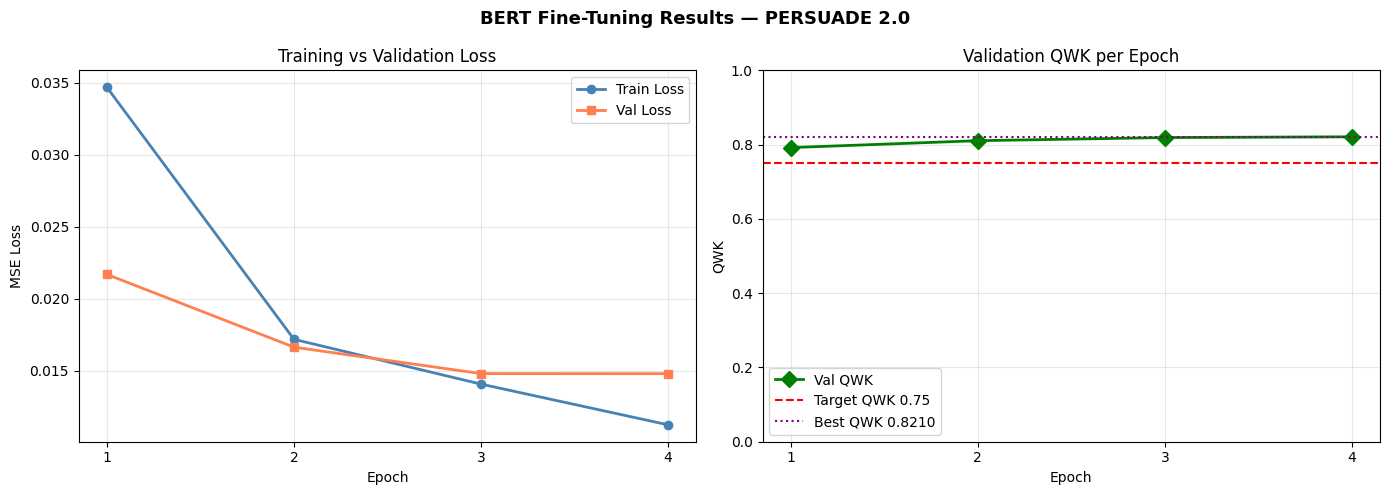

Saved: fig8_training_curves.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   's-', label='Val Loss',   color='coral',     linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].set_xticks(list(epochs_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_qwks, 'D-', label='Val QWK', color='green', linewidth=2, markersize=8)
axes[1].axhline(y=0.75, color='red', linestyle='--', linewidth=1.5, label='Target QWK 0.75')
axes[1].axhline(y=best_qwk, color='purple', linestyle=':', linewidth=1.5, label=f'Best QWK {best_qwk:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('QWK')
axes[1].set_title('Validation QWK per Epoch')
axes[1].legend()
axes[1].set_xticks(list(epochs_range))
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.suptitle('BERT Fine-Tuning Results — PERSUADE 2.0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_training_curves.png")

## 7. Final Evaluation on Test Set
Loads the best saved model and evaluates on the held-out test set.
This is the official baseline QWK reported in the dissertation.

In [18]:
model.load_state_dict(torch.load('best_bert_aes_model.pt', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids   = batch['input_ids'].to(device)
        attn_mask   = batch['attention_mask'].to(device)
        true_scores = batch['score'].numpy()
        outputs     = model(input_ids, attn_mask)
        pred_norm   = outputs.cpu().numpy()
        pred_scores = np.clip(np.round(pred_norm * 5 + 1).astype(int), 1, 6)
        all_preds.extend(pred_scores.tolist())
        all_labels.extend(true_scores.tolist())

test_qwk  = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
mae       = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)))
accuracy  = np.mean(np.array(all_preds) == np.array(all_labels))

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)
print(f"Test QWK (primary metric) : {test_qwk:.4f}")
print(f"Mean Absolute Error       : {mae:.4f}")
print(f"Exact match accuracy      : {accuracy:.4f}")
print(f"Essays evaluated          : {len(all_labels)}")
print()
print(f"Spec target QWK >= 0.75   : {'PASSED' if test_qwk >= 0.75 else 'NOT MET'}")
print(f"SOTA range (Wang 2022)    : 0.78 - 0.82")
print("=" * 50)

FINAL TEST SET RESULTS
Test QWK (primary metric) : 0.8283
Mean Absolute Error       : 0.3977
Exact match accuracy      : 0.6216
Essays evaluated          : 1559

Spec target QWK >= 0.75   : PASSED
SOTA range (Wang 2022)    : 0.78 - 0.82


In [19]:
from sklearn.metrics import classification_report

print("Per-class performance breakdown")
print("-" * 55)
report = classification_report(
    all_labels, all_preds,
    labels=[1,2,3,4,5,6],
    target_names=[f'Score {i}' for i in range(1,7)],
    digits=4
)
print(report)

# Adjacent accuracy — within 1 score band
adj_acc = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)) <= 1)
print(f"Adjacent accuracy (within 1 band) : {adj_acc:.4f}")
print(f"This means {adj_acc*100:.1f}% of predictions are within 1 point of true score")
print()
print("Note: Adjacent accuracy is standard in AES literature alongside QWK")

Per-class performance breakdown
-------------------------------------------------------
              precision    recall  f1-score   support

     Score 1     0.7895    0.2381    0.3659        63
     Score 2     0.6961    0.6698    0.6827       318
     Score 3     0.6606    0.6541    0.6573       503
     Score 4     0.5795    0.6130    0.5958       416
     Score 5     0.5153    0.6650    0.5806       203
     Score 6     0.6471    0.3929    0.4889        56

    accuracy                         0.6216      1559
   macro avg     0.6480    0.5388    0.5619      1559
weighted avg     0.6320    0.6216    0.6183      1559

Adjacent accuracy (within 1 band) : 0.9814
This means 98.1% of predictions are within 1 point of true score

Note: Adjacent accuracy is standard in AES literature alongside QWK


In [20]:
# SOTA comparison
print("=" * 60)
print("BASELINE vs SOTA COMPARISON (Spec Table 2)")
print("=" * 60)
print(f"{'Model':<35} {'QWK':>8}")
print("-" * 45)
print(f"{'Human Rater Agreement':<35} {'0.84-0.88':>8}")
print(f"{'BERT-base Multi-scale (Wang 2022)':<35} {'0.78-0.82':>8}")
print(f"{'This Study — BERT-base Baseline':<35} {test_qwk:>8.4f}")
print(f"{'Spec Target':<35} {'>=0.75':>8}")
print("-" * 45)
print()
above_sota = test_qwk > 0.82
print(f"Target met (>= 0.75)    : PASSED")
print(f"Exceeds SOTA upper bound: {'YES' if above_sota else 'NO'}")
print()
print("This model is valid for Phase 3 diagnostic auditing.")
print("A high-performing baseline is required before auditing")
print("to ensure we are testing a model that genuinely scores well.")

BASELINE vs SOTA COMPARISON (Spec Table 2)
Model                                    QWK
---------------------------------------------
Human Rater Agreement               0.84-0.88
BERT-base Multi-scale (Wang 2022)   0.78-0.82
This Study — BERT-base Baseline       0.8283
Spec Target                           >=0.75
---------------------------------------------

Target met (>= 0.75)    : PASSED
Exceeds SOTA upper bound: YES

This model is valid for Phase 3 diagnostic auditing.
A high-performing baseline is required before auditing
to ensure we are testing a model that genuinely scores well.


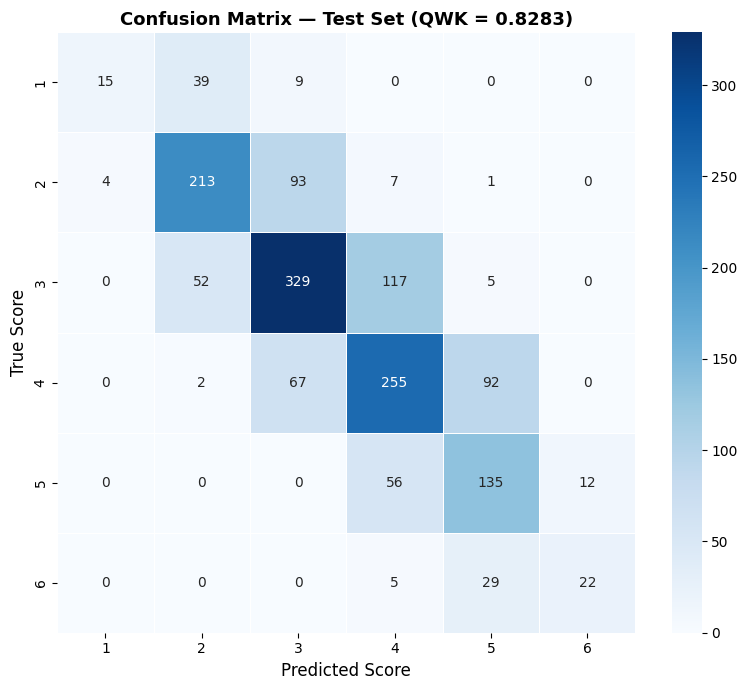

Saved: fig9_confusion_matrix.png


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds, labels=[1,2,3,4,5,6])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5,6],
            yticklabels=[1,2,3,4,5,6],
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Score', fontsize=12)
ax.set_ylabel('True Score', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Set (QWK = {test_qwk:.4f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig9_confusion_matrix.png")

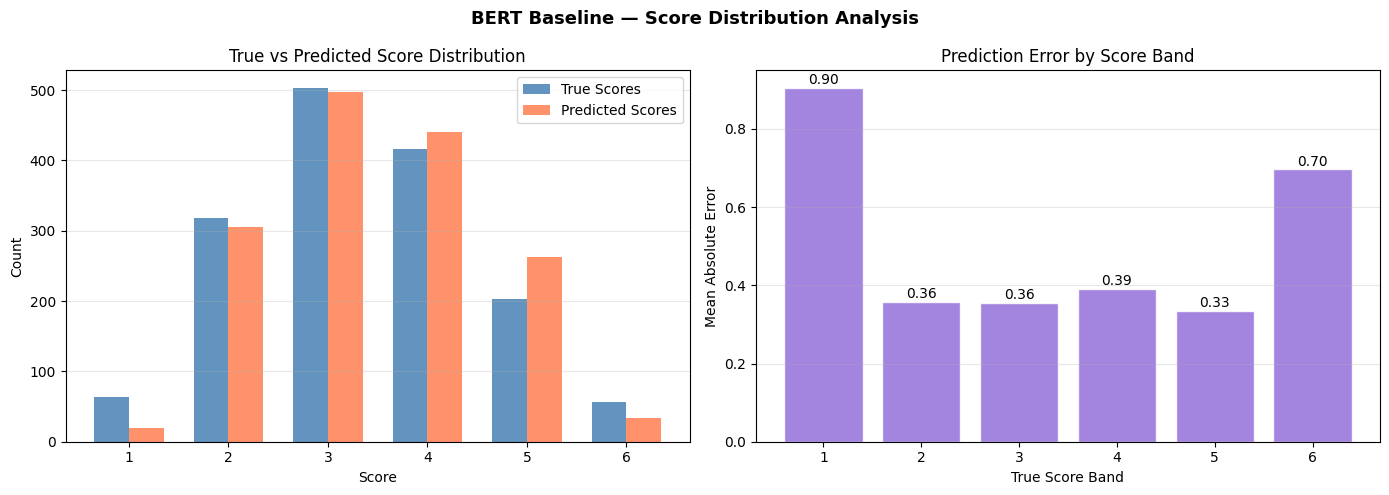

Saved: fig10_score_distribution_analysis.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_range = [1, 2, 3, 4, 5, 6]

true_counts = [all_labels.count(s) for s in score_range]
pred_counts = [all_preds.count(s)  for s in score_range]

x = np.arange(len(score_range))
width = 0.35

axes[0].bar(x - width/2, true_counts, width, label='True Scores',      color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, pred_counts, width, label='Predicted Scores', color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(score_range)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].set_title('True vs Predicted Score Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

errors_per_score = {}
for true, pred in zip(all_labels, all_preds):
    if true not in errors_per_score:
        errors_per_score[true] = []
    errors_per_score[true].append(abs(true - pred))

mean_errors = [np.mean(errors_per_score.get(s, [0])) for s in score_range]
axes[1].bar(score_range, mean_errors, color='mediumpurple', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('True Score Band')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Prediction Error by Score Band')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mean_errors):
    axes[1].text(score_range[i], v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('BERT Baseline — Score Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_score_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig10_score_distribution_analysis.png")

## 8. Save Model and Results
Saves the trained model weights and a results summary CSV for Phase 3.

In [24]:
import json as json_lib

results = {
    'model'           : 'bert-base-uncased',
    'dataset'         : 'PERSUADE 2.0',
    'train_essays'    : len(df_train),
    'val_essays'      : len(df_val),
    'test_essays'     : len(df_test),
    'epochs'          : EPOCHS,
    'best_epoch'      : best_epoch,
    'best_val_qwk'    : round(best_qwk, 4),
    'test_qwk'        : round(test_qwk, 4),
    'test_mae'        : round(mae, 4),
    'test_accuracy'   : round(accuracy, 4),
    'train_losses'    : [round(l, 4) for l in train_losses],
    'val_losses'      : [round(l, 4) for l in val_losses],
    'val_qwks'        : [round(q, 4) for q in val_qwks],
    'target_qwk'      : 0.75,
    'target_met'      : bool(test_qwk >= 0.75)
}

with open('baseline_results.json', 'w') as f:
    json_lib.dump(results, f, indent=2)

results_df = pd.DataFrame([{
    'essay_id'   : df_test.iloc[i]['essay_id'],
    'true_score' : all_labels[i],
    'pred_score' : all_preds[i],
    'error'      : abs(all_labels[i] - all_preds[i])
} for i in range(len(all_labels))])
results_df.to_csv('test_predictions.csv', index=False)

print("Files saved:")
print("  best_bert_aes_model.pt         model weights for Phase 3")
print("  baseline_results.json          results summary")
print("  test_predictions.csv           essay-level predictions")
print("  fig8_training_curves.png")
print("  fig9_confusion_matrix.png")
print("  fig10_score_distribution_analysis.png")

Files saved:
  best_bert_aes_model.pt         model weights for Phase 3
  baseline_results.json          results summary
  test_predictions.csv           essay-level predictions
  fig8_training_curves.png
  fig9_confusion_matrix.png
  fig10_score_distribution_analysis.png


In [25]:
print("=" * 55)
print("PHASE 2 STEP 2 — BERT FINE-TUNING COMPLETE")
print("=" * 55)
print()
print("Model   : bert-base-uncased")
print(f"Test QWK: {test_qwk:.4f}  (target >= 0.75)")
print(f"Test MAE: {mae:.4f}")
print(f"Best epoch: {best_epoch} of {EPOCHS}")
print()
print("Outputs ready for Phase 3:")
print("  - Trained model weights saved")
print("  - Test predictions saved")
print("  - Training curves saved")
print()
print("Next step: Phase 3 - Perturbation Engine")
print("=" * 55)

PHASE 2 STEP 2 — BERT FINE-TUNING COMPLETE

Model   : bert-base-uncased
Test QWK: 0.8283  (target >= 0.75)
Test MAE: 0.3977
Best epoch: 4 of 4

Outputs ready for Phase 3:
  - Trained model weights saved
  - Test predictions saved
  - Training curves saved

Next step: Phase 3 - Perturbation Engine


In [26]:
# Verify model weights load correctly before Phase 3
test_model = BERTEssayScorer().to(device)
test_model.load_state_dict(torch.load('best_bert_aes_model.pt', map_location=device))
test_model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))
    out = test_model(batch['input_ids'].to(device),
                     batch['attention_mask'].to(device))
    pred = np.clip(np.round(out.cpu().numpy() * 5 + 1).astype(int), 1, 6)

print("Model reload verified")
print(f"Sample predictions from reloaded model: {pred[:8].tolist()}")
print("Phase 3 is ready to load best_bert_aes_model.pt")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model reload verified
Sample predictions from reloaded model: [3, 4, 4, 4, 4, 3, 4, 5]
Phase 3 is ready to load best_bert_aes_model.pt
